Testing ways to read a data file generated by a separate running program.

The following example is from https://stackoverflow.com/questions/5419888/reading-from-a-frequently-updated-file (slightly modified).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# follow.py
#
# Follow a file like tail -f.

import time
def follow(thefile):
#    thefile.seek(0,2)
    while True:
        line = thefile.readline()
        if not line:
            time.sleep(0.1)
            continue
        yield line

if __name__ == '__main__':
    logfile = open("temp","r")
    for line in logfile:
        print(line,)
    loglines = follow(logfile)
    for line in loglines:
        if line == '-999': # This is the end condition.
            print(line,)
            break
        print(line,)

1

2

3

4

75

999

29586

982659

3982673926

29586

29586

-999

-999, 983467948

395687

396873926

-999

39567329567

-999

1234

9876

-999


-1234

-999


In [36]:
a = "123 345\n"

In [37]:
a

'123 345\n'

In [38]:
print(a)

123 345



In [39]:
a.split()

['123', '345']

In [40]:
np.float(a.split()[0])

123.0

In [41]:
np.array(a.split(), np.float)

array([123., 345.])

In [44]:
np.fromstring(a, sep=' ')

array([123., 345.])

In [56]:
logfile.close()

In [47]:
np.loadtxt('temp')

array([ 1.00000000e+00,  2.00000000e+00,  3.00000000e+00,  4.00000000e+00,
        7.50000000e+01,  9.99000000e+02,  2.95860000e+04,  9.82659000e+05,
        3.98267393e+09,  2.95860000e+04,  2.95860000e+04, -9.99000000e+02,
       -9.99000000e+02,  3.95687000e+05,  3.96873926e+08, -9.99000000e+02,
        3.95673296e+10, -9.99000000e+02,  1.23400000e+03,  9.87600000e+03,
       -9.99000000e+02, -1.23400000e+03, -9.99000000e+02])

In [65]:
# Now see if we can plot it.

import time
def follow(thefile):
#    thefile.seek(0,2)
    while True:
        line = thefile.readline()
        if not line:
            time.sleep(0.1)
            continue
        yield line

if __name__ == '__main__':
    logfile = open("temp","r")
    olddata = np.loadtxt(logfile)
    print(olddata)
    partial = ''
    loglines = follow(logfile)
    for line in loglines:
        if line == '-999': # This is the end condition.
            newdata = np.fromstring(partial + line, sep=' ')
            print(newdata)
            break
        if line[-1] == '\n':
            newdata = np.fromstring(partial + line, sep=' ')
            print(newdata)
            partial = ''
        else:
            partial = line
    # Not following any more. Close file.
    logfile.close()

[ 1.00000000e+00  2.00000000e+00  3.00000000e+00  4.00000000e+00
  7.50000000e+01  9.99000000e+02  2.95860000e+04  9.82659000e+05
  3.98267393e+09  2.95860000e+04  2.95860000e+04 -9.99000000e+02
 -9.99000000e+02  3.95687000e+05  3.96873926e+08 -9.99000000e+02
  3.95673296e+10 -9.99000000e+02  1.23400000e+03  9.87600000e+03
 -9.99000000e+02 -1.23400000e+03 -9.99000000e+02  1.23000000e+02
  4.56000000e+02  1.11123000e+05  1.23400000e+03  1.23400000e+03
  1.23450000e+04  1.00000000e+00  2.00000000e+00  3.00000000e+00
  4.00000000e+00  5.00000000e+00  1.23000000e+02  1.23400000e+03
  5.67800000e+03  9.00000000e+00  1.00000000e+01 -9.99000000e+02
  1.23456000e+05  7.89000000e+02  1.01112000e+05 -9.99000000e+02
  1.20000000e+01  1.20000000e+01  1.30000000e+01 -9.99000000e+02]
[-1.]
[12.]
[-999.]


In [66]:
logfile.closed

True

In [72]:
logfile = open("temp","r")
olddata = np.genfromtxt(logfile, skip_footer=1)
print(olddata)
line = logfile.readline()
newdata = np.fromstring(partial + line, sep=' ')
print(newdata)
logfile.close()

[1.00000000e+00 2.00000000e+00 3.00000000e+00 4.00000000e+00
 7.50000000e+01 9.99000000e+02 2.95860000e+04 9.82659000e+05
 3.98267393e+09]
[]


In [88]:
# Now see if we can plot it.

import time
def follow(thefile):
#    thefile.seek(0,2)
    while True:
        line = thefile.readline()
        if not line:
            time.sleep(0.1)
            continue
        yield line

if __name__ == '__main__':
    data = np.array([])
    with open("temp","r") as logfile:
        partial = ''
        for line in logfile:
            if line[-1] == '\n':
                data = np.append(data, np.fromstring(partial + line, sep=' '))
                partial = ''
            else:
                partial = line
        print(data)
        loglines = follow(logfile)
        for line in loglines:
            if line == '-999': # This is the end condition.
                newdata = np.fromstring(partial + line, sep=' ')
                data = np.append(data, newdata)
                print(newdata)
                break
            if line[-1] == '\n':
                newdata = np.fromstring(partial + line, sep=' ')
                print(newdata)
                data = np.append(data, newdata)
                partial = ''
            else:
                partial = line
    print('All the data\n', data)

[ 1.  2.  3.  4. 75. 45.]
[76.]
[56.]
[1.]
[2.]
[3.]
[-999.]
All the data
 [   1.    2.    3.    4.   75.   45.   76.   56.    1.    2.    3. -999.]


In [89]:
data[-1]

-999.0

In [90]:
data[3]

4.0

In [2]:
def monitor():
    import time
    def follow(thefile):
    #    thefile.seek(0,2)
        while True:
            line = thefile.readline()
            if not line:
                time.sleep(0.1)
                continue
            yield line

    data = np.array([])
    with open("temp","r") as logfile:
        partial = ''
        for line in logfile:
            if line[-1] == '\n':
                data = np.append(data, np.fromstring(partial + line, sep=' '))
                partial = ''
            else:
                partial = line
        print(data)
        loglines = follow(logfile)
        for line in loglines:
            if line == '-999': # This is the end condition.
                newdata = np.fromstring(partial + line, sep=' ')
                data = np.append(data, newdata)
                print(newdata)
                break
            if line[-1] == '\n':
                newdata = np.fromstring(partial + line, sep=' ')
                print(newdata)
                data = np.append(data, newdata)
                partial = ''
            else:
                partial = line
    print('All the data\n', data)

In [3]:
monitor()

[  1234.   5678. 123333.   -999.   -999.]
[123.]
[-999.]
All the data
 [ 1.23400e+03  5.67800e+03  1.23333e+05 -9.99000e+02 -9.99000e+02
  1.23000e+02 -9.99000e+02]


In [5]:
data = np.array([1,1,1,2,2,2,3,4,5,5,5,6,6,7,7,7,7,7,8,8,9])

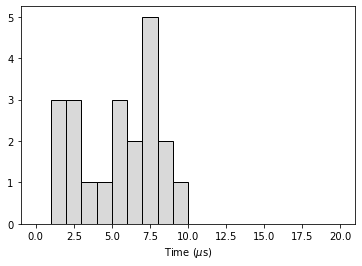

In [20]:
fig, ax = plt.subplots()
hist, bin_edges, _ = ax.hist(data, bins = 20, range = [0, 20], edgecolor='black', facecolor='0.85')
ax.set_xlabel(r'Time ($\mu$s)')
fig.canvas.draw()

In [11]:
hist, bin_edges, _ = ax.hist(data, bins = 20, range = [0, 20])

In [12]:
fig.show()

/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  """Entry point for launching an IPython kernel.
